<a href="https://colab.research.google.com/github/Touseeq99/ML_MODELS_SCRATCH/blob/main/CNN_RIPNESS_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import torch
import torch.nn as nn
import torch.optim as op
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader , Dataset
from torchvision import datasets , transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
from sklearn.metrics import confusion_matrix, classification_report
import os

In [53]:
transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5],
                         std=[0.5,0.5,0.5])
])

In [54]:
test_ds = ImageFolder(root="/content/DATA/test" , transform=transforms)
train_ds = ImageFolder(root="/content/DATA/train" , transform=transforms)

In [55]:
train_loader = DataLoader(train_ds , batch_size=32 , shuffle=True)
test_loader = DataLoader(test_ds , batch_size=32 , shuffle=False)

In [35]:
images , labels = next(iter(train_ds))

###CNN CLASS

In [56]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN , self).__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(3 , 16 , 3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16 , 64 , 3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*32*32 , 128),
        nn.ReLU(),
        nn.Linear(128 , 4)
    )

  def forward(self , x):
    x = self.conv1(x)
    x = self.fc(x)
    return x

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [57]:
device

device(type='cpu')

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = op.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_loss = []
train_accuracies = []
val_accuracies = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total

    train_loss.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

    model.eval()
    val_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            val_total += labels.size(0)
    val_acc = val_corrects.double() / val_total
    val_accuracies.append(val_acc.item())


    torch.save(model.state_dict(), 'best_banana_cnn.pth')

    print(f"Validation Accuracy: {val_acc:.4f}")

Epoch 1/10, Loss: 1.6863, Accuracy: 0.4063
Validation Accuracy: 0.6364
Epoch 2/10, Loss: 0.8833, Accuracy: 0.7137
Validation Accuracy: 0.6727
Epoch 3/10, Loss: 0.5435, Accuracy: 0.7768
Validation Accuracy: 0.8000
Epoch 4/10, Loss: 0.4068, Accuracy: 0.8505
Validation Accuracy: 0.8000
Epoch 5/10, Loss: 0.2938, Accuracy: 0.8863
Validation Accuracy: 0.9091
Epoch 6/10, Loss: 0.2083, Accuracy: 0.9284
Validation Accuracy: 0.8364
Epoch 7/10, Loss: 0.1876, Accuracy: 0.9263
Validation Accuracy: 0.8545
Epoch 8/10, Loss: 0.1928, Accuracy: 0.9158
Validation Accuracy: 0.9273
Epoch 9/10, Loss: 0.1545, Accuracy: 0.9347
Validation Accuracy: 0.9091
Epoch 10/10, Loss: 0.1409, Accuracy: 0.9495
Validation Accuracy: 0.9273


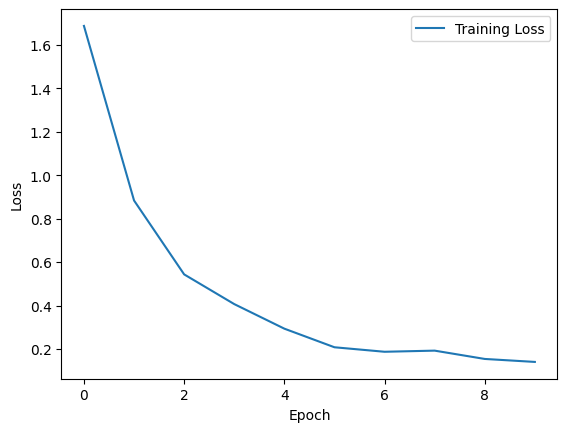

In [62]:
plt.plot(train_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

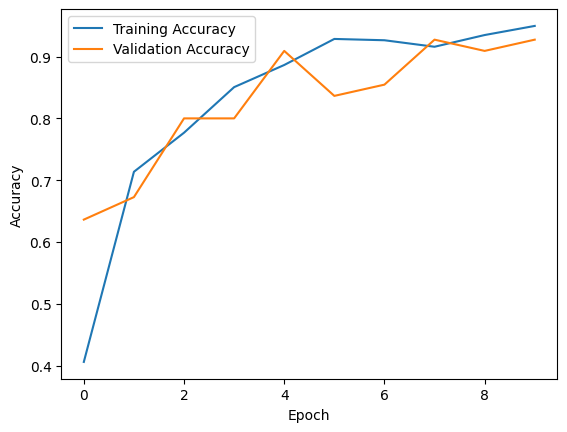

In [63]:
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [66]:
testimage = "/content/DATA/train/3.Matang/m001_jpg.rf.848fabb5f354952783528281cec5ce1e.jpg"

In [77]:
from PIL import Image

In [78]:
test = Image.open(testimage)

In [70]:
t = torch.tensor(np.array(test))

In [72]:
model = CNN()
model.load_state_dict(torch.load('best_banana_cnn.pth'))
model.eval() # Set the model to evaluation mode

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [75]:
from torchvision import transforms


In [80]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

img = transform(test).unsqueeze(0)
img = img.to(device)

In [83]:
with torch.no_grad():
    outputs = model(img)
    _, predicted = torch.max(outputs, 1)
    print(predicted)

tensor([2])


In [84]:
print(predicted.item())

2


In [82]:
class_names = train_ds.classes
label = class_names[predicted.item()]
print("Predicted class:", label)


Predicted class: 3.Matang
